**Our project investigates how different activation functions, specifically Sigmoid and ReLU, affect the training and classification performance of a neural network on image data using the MNIST dataset.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import mnist

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


**NumPy** → numerical operations

**Pandas** → organizing results/metrics

**Matplotlib** → plots and visualizations

**Seaborn** → confusion-matrix visualization

**TensorFlow/Keras** → build and train our neural
networks

**Scikit-learn** → evaluation metrics

**Why did you use TensorFlow/Keras?**

It provides a high-level API for building, training, and evaluating neural networks efficiently.

In [ ]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


**60,000** training images

**10,000** testing images

Each image is **28 x 28 pixels**

Each image represents a handwritten digit
from **0-9**

An image is made up of many tiny points called **pixels.**

Our MNIST image has:

28×28=784 pixels

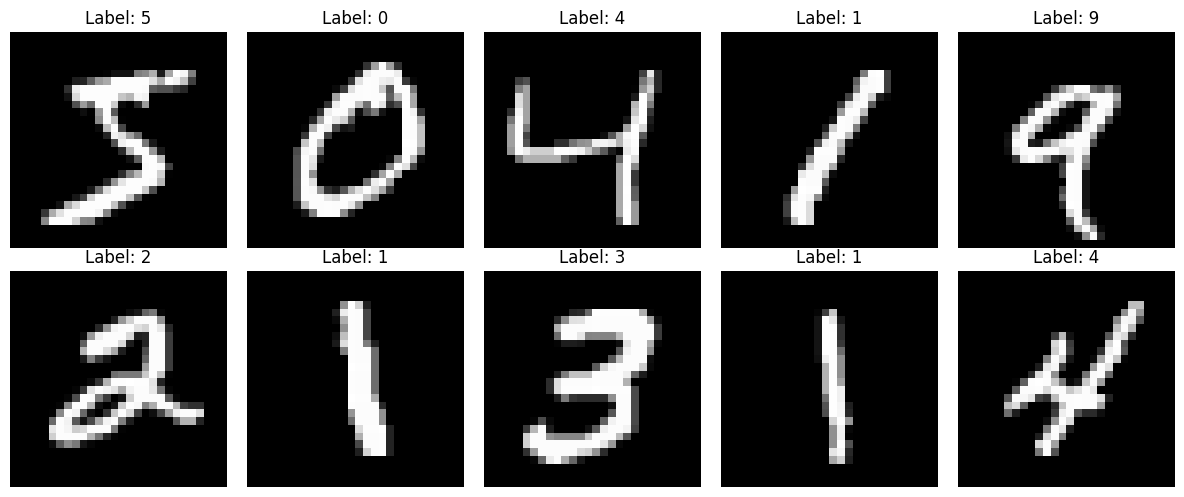

In [ ]:
# Display 10 sample images

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Image shape:", X_train[0].shape)
print("Minimum pixel value:", X_train[0].min())
print("Maximum pixel value:", X_train[0].max())
print("Label:", y_train[0])

Image shape: (28, 28)
Minimum pixel value: 0
Maximum pixel value: 255
Label: 5


**What do 0 and 255 mean?**

Because MNIST is a grayscale image:

**Pixel value	Meaning** :

**0	- Completely black**

**255	- Completely white**

**128	- Gray**

**50 - Very dark gray**

**200 -	Very light gray**

In [ ]:
# Normalize pixel values to the range 0–1

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


**Reshape the images**

In [ ]:
# Flatten the 28x28 images into 784-dimensional vectors

X_train_flat = X_train.reshape(X_train.shape[0], 784)
X_test_flat = X_test.reshape(X_test.shape[0], 784)

print("Training data shape:", X_train_flat.shape)
print("Testing data shape:", X_test_flat.shape)

Training data shape: (60000, 784)
Testing data shape: (10000, 784)


## Understanding the 784 Input Features

Each MNIST image has a size of **28 × 28 pixels**.

Therefore, each image contains:

**28 × 28 = 784 pixels**

Each pixel has an **intensity value** that represents how bright or dark that pixel is.

Before normalization, pixel values range from **0 to 255**:

- **0** → black
- **255** → white
- Values between 0 and 255 → different shades of gray

After normalization, the values are converted to the range **0 to 1** by dividing each pixel value by 255.

For example:

- 0 → 0.00
- 128 → 0.502
- 255 → 1.00

### Flattening the Image

The original image has a two-dimensional shape:

**28 × 28**

For a fully connected neural network, we flatten it into a one-dimensional vector containing **784 pixel intensity values**.

For example:

```text
[0.00, 0.12, 0.35, 0.454, ..., 0.02]
```

**Build the Neural Network**

**1) Sigmoid Model**

In [ ]:
# Build a neural network using Sigmoid activation

sigmoid_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),

    tf.keras.layers.Dense(128, activation="sigmoid"),
    tf.keras.layers.Dense(64, activation="sigmoid"),

    tf.keras.layers.Dense(10, activation="softmax")
])

sigmoid_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Input** -> 784 pixels

**Hidden Layer 1** -> 128 neurons (Sigmoid)

**Hidden Layer 2** -> 64 neurons (Sigmoid)

**Output** -> 10 neurons (Softmax)

## Softmax

Softmax converts the 10 output values into probabilities between 0 and 1.  
The probabilities add up to 1, and the class with the highest probability is selected as the prediction.

Example:

0 → 0.01

1 → 0.02

...

9 → 0.90  ← highest

Therefore, model predicts **9**

**Weighted Calculation**

Each neuron receives all inputs and their corresponding weights.

**Weighted Sum = (x₁×w₁) + (x₂×w₂) + ... + (xₙ×wₙ) + bias**

Example:

```text
Inputs:   [0.2, 0.5, 0.8]
Weights:  [0.4, 0.6, 0.3]
Bias:      0.1

(0.2×0.4) + (0.5×0.6) + (0.8×0.3) + 0.1
= 0.72
```

This is for 1 neuron

### 1️⃣ First layer: 784 → 128

Each of the **128 neurons**:

- receives all 784 inputs
- performs weighted calculation + bias
- applies **Sigmoid**
- produces **1 value**

So → **128 output values**

### 2️⃣ Second layer: 128 → 64

Each of the **64 neurons**:

- receives all 128 values
- performs weighted calculation + bias
- applies **Sigmoid**
- produces **1 value**

So → **64 output values**

### 3️⃣ Output layer: 64 → 10

Each of the **10 neurons**:

- receives all 64 values
- performs weighted calculation + bias
- produces a final score
- **Softmax** converts the 10 scores into probabilities

So → **10 probabilities for digits 0–9**.

**Training Sigmoid Model**

In [ ]:
sigmoid_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sigmoid = sigmoid_model.fit(
    X_train_flat,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8033 - loss: 0.8336 - val_accuracy: 0.9250 - val_loss: 0.2938
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9199 - loss: 0.2901 - val_accuracy: 0.9427 - val_loss: 0.1987
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9376 - loss: 0.2173 - val_accuracy: 0.9575 - val_loss: 0.1605
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9496 - loss: 0.1743 - val_accuracy: 0.9637 - val_loss: 0.1336
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9577 - loss: 0.1448 - val_accuracy: 0.9667 - val_loss: 0.1190
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9651 - loss: 0.1218 - val_accuracy: 0.9690 - val_loss: 0.1070
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9708 - loss: 0.1035 - val_accuracy: 0.9713 - val_loss: 0.0988
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9749 - loss: 0.0896 - val_accuracy: 0.

**10 epochs means the model goes through the entire training dataset 10 times.**

**Evaluate the Model**

In [ ]:
test_loss_sigmoid, test_accuracy_sigmoid = sigmoid_model.evaluate(
    X_test_flat,
    y_test
)

print("Sigmoid Test Accuracy:", test_accuracy_sigmoid)
print("Sigmoid Test Loss:", test_loss_sigmoid)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9733 - loss: 0.0860
Sigmoid Test Accuracy: 0.9732999801635742
Sigmoid Test Loss: 0.08597781509160995


In [ ]:
# Make predictions using the Sigmoid model

y_pred_sigmoid = sigmoid_model.predict(X_test_flat)

print("Prediction shape:", y_pred_sigmoid.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Prediction shape: (10000, 10)


### Model Predictions

We have **10,000 test images**.

For each image, the model produces **10 probabilities**:

```text
Image 1 → [P(0), P(1), P(2), ..., P(9)]
Image 2 → [P(0), P(1), P(2), ..., P(9)]
...
Image 10000 → [P(0), P(1), ..., P(9)]
```

For example:

```
[0.01, 0.00, 0.02, 0.00, 0.01, 0.00, 0.00, 0.03, 0.02, 0.91]
```

The highest probability is 0.91, corresponding to digit 9.

Therefore, the model predicts 9.

In [ ]:
# Convert probabilities into predicted class labels

y_pred_sigmoid_labels = np.argmax(y_pred_sigmoid, axis=1)

print("First 10 predicted labels:", y_pred_sigmoid_labels[:10])
print("First 10 actual labels:", y_test[:10])

First 10 predicted labels: [7 2 1 0 4 1 4 9 6 9]
First 10 actual labels: [7 2 1 0 4 1 4 9 5 9]


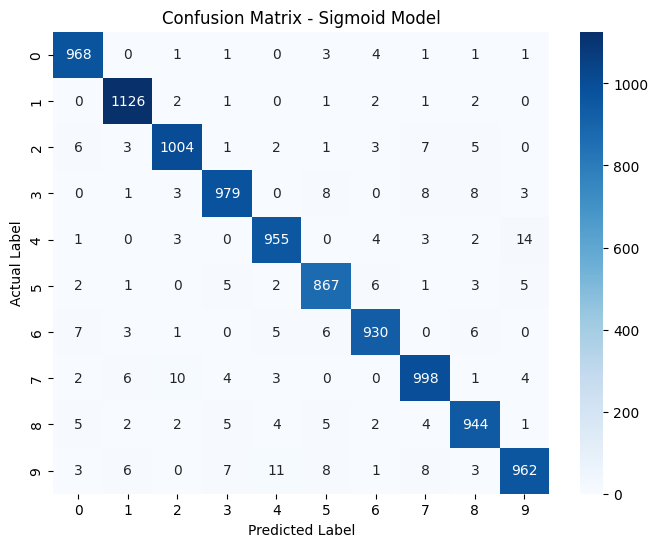

In [ ]:
# Create confusion matrix for the Sigmoid model

cm_sigmoid = confusion_matrix(y_test, y_pred_sigmoid_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_sigmoid, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Sigmoid Model")

plt.show()

In [ ]:
# Classification report for Sigmoid model

print("Classification Report - Sigmoid Model\n")

print(classification_report(
    y_test,
    y_pred_sigmoid_labels
))

Classification Report - Sigmoid Model

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.98      0.97      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.96      0.97      0.97       892
           6       0.98      0.97      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



**2) ReLU Model**

In [ ]:
relu_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(10, activation="softmax")
])

relu_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Training ReLU Model**

In [ ]:
relu_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the ReLU model
history_relu = relu_model.fit(
    X_train_flat,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8995 - loss: 0.3572 - val_accuracy: 0.9577 - val_loss: 0.1466
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9573 - loss: 0.1425 - val_accuracy: 0.9703 - val_loss: 0.1079
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9702 - loss: 0.0991 - val_accuracy: 0.9720 - val_loss: 0.0942
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9777 - loss: 0.0734 - val_accuracy: 0.9727 - val_loss: 0.0947
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9826 - loss: 0.0574 - val_accuracy: 0.9762 - val_loss: 0.0815
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9858 - loss: 0.0463 - val_accuracy: 0.9772 - val_loss: 0.0825
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9893 - loss: 0.0359 - val_accuracy: 0.9773 - val_loss: 0.0874
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9910 - loss: 0.0307 - val_accuracy: 0.

| Component    | Purpose                                   |
| ------------ | ----------------------------------------- |
| **Adam**     | Updates weights and biases                |
| **Loss**     | Measures how wrong the prediction is      |
| **Accuracy** | Measures how many predictions are correct |


**Evaluate the Model**

In [ ]:
test_loss_relu, test_accuracy_relu = relu_model.evaluate(
    X_test_flat,
    y_test
)

print("ReLU Test Accuracy:", test_accuracy_relu)
print("ReLU Test Loss:", test_loss_relu)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9770 - loss: 0.0786
ReLU Test Accuracy: 0.9769999980926514
ReLU Test Loss: 0.07861501723527908


In [ ]:
# Make predictions using the ReLU model

y_pred_relu = relu_model.predict(X_test_flat)

print("Prediction shape:", y_pred_relu.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Prediction shape: (10000, 10)


In [ ]:
# Convert probabilities into predicted class labels

y_pred_relu_labels = np.argmax(y_pred_relu, axis=1)

print("First 10 predicted labels:", y_pred_relu_labels[:10])
print("First 10 actual labels:", y_test[:10])

First 10 predicted labels: [7 2 1 0 4 1 4 9 6 9]
First 10 actual labels: [7 2 1 0 4 1 4 9 5 9]


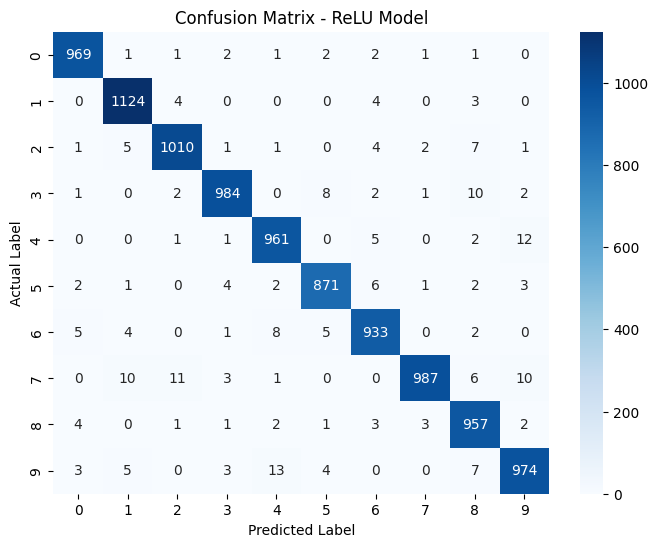

In [ ]:
# Create confusion matrix for the ReLU model

cm_relu = confusion_matrix(y_test, y_pred_relu_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_relu, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - ReLU Model")

plt.show()

In [ ]:
# Classification report for ReLU model

print("Classification Report - ReLU Model\n")

print(classification_report(
    y_test,
    y_pred_relu_labels
))

Classification Report - ReLU Model

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.98      0.99      0.98      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.97      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.97      0.97      0.97       958
           7       0.99      0.96      0.98      1028
           8       0.96      0.98      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



**Comparing training accuracy of Sigmoid and ReLU**

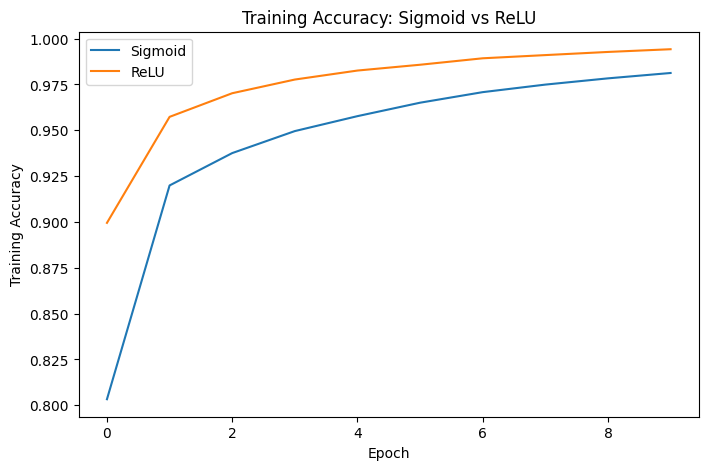

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_sigmoid.history["accuracy"], label="Sigmoid")
plt.plot(history_relu.history["accuracy"], label="ReLU")

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy: Sigmoid vs ReLU")
plt.legend()
plt.show()

**Validation Accuracy**

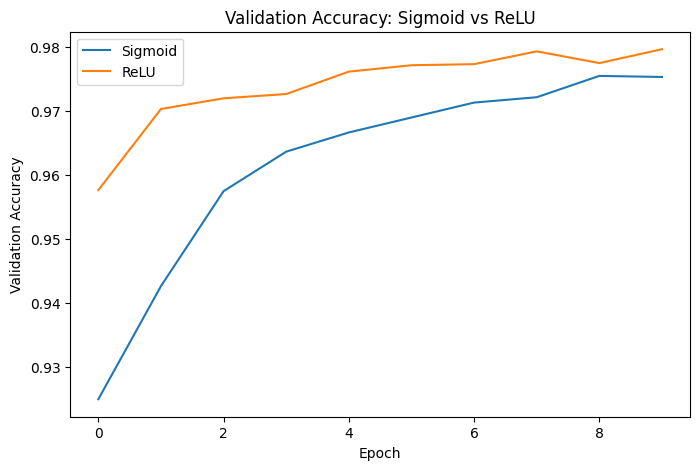

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_sigmoid.history["val_accuracy"], label="Sigmoid")
plt.plot(history_relu.history["val_accuracy"], label="ReLU")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Sigmoid vs ReLU")
plt.legend()
plt.show()

**Compare Training Loss**

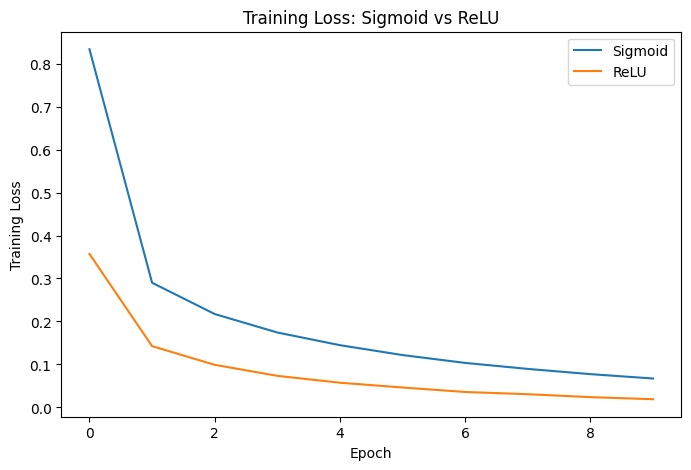

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_sigmoid.history["loss"], label="Sigmoid")
plt.plot(history_relu.history["loss"], label="ReLU")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: Sigmoid vs ReLU")
plt.legend()
plt.show()

**Compare Validation Loss**

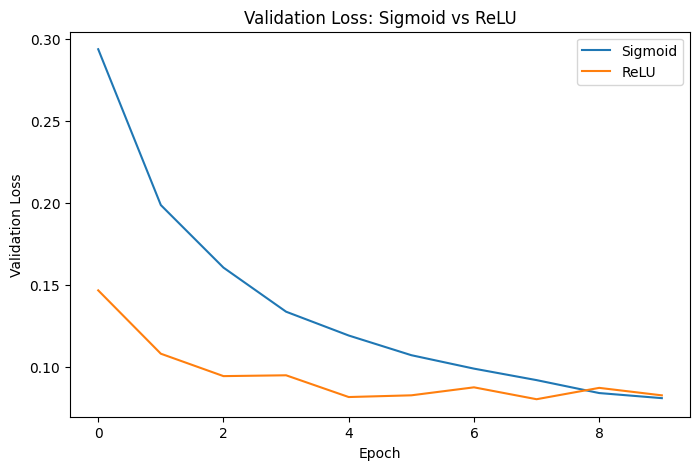

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history_sigmoid.history["val_loss"], label="Sigmoid")
plt.plot(history_relu.history["val_loss"], label="ReLU")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Sigmoid vs ReLU")
plt.legend()
plt.show()

**Final Comparison Table**

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Sigmoid", "ReLU"],
    "Test Accuracy": [test_accuracy_sigmoid, test_accuracy_relu],
    "Test Loss": [test_loss_sigmoid, test_loss_relu]
})

comparison

,Model,Test Accuracy,Test Loss
0,Sigmoid,0.9733,0.085978
1,ReLU,0.9770,0.078615


**Accuracy as Percentage**

In [ ]:
print("Sigmoid Test Accuracy:", test_accuracy_sigmoid * 100, "%")
print("ReLU Test Accuracy:", test_accuracy_relu * 100, "%")

Sigmoid Test Accuracy: 97.32999801635742 %
ReLU Test Accuracy: 97.69999980926514 %


**Visualize Final Test Accuracy**

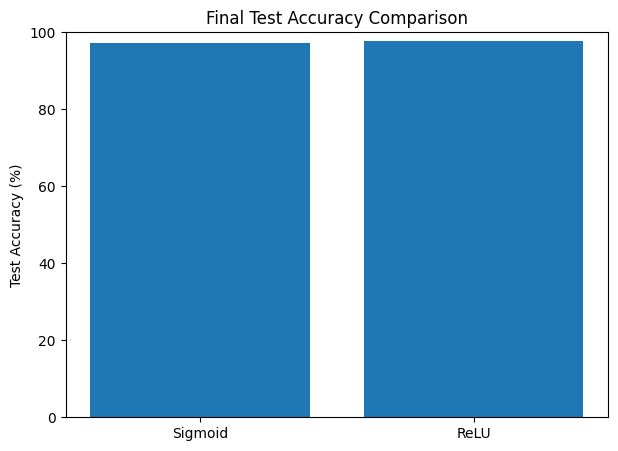

In [ ]:
models = ["Sigmoid", "ReLU"]
accuracies = [test_accuracy_sigmoid * 100, test_accuracy_relu * 100]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.title("Final Test Accuracy Comparison")
plt.ylim(0, 100)

plt.show()

**Classified Images for ReLU**

Total correctly classified: 9770


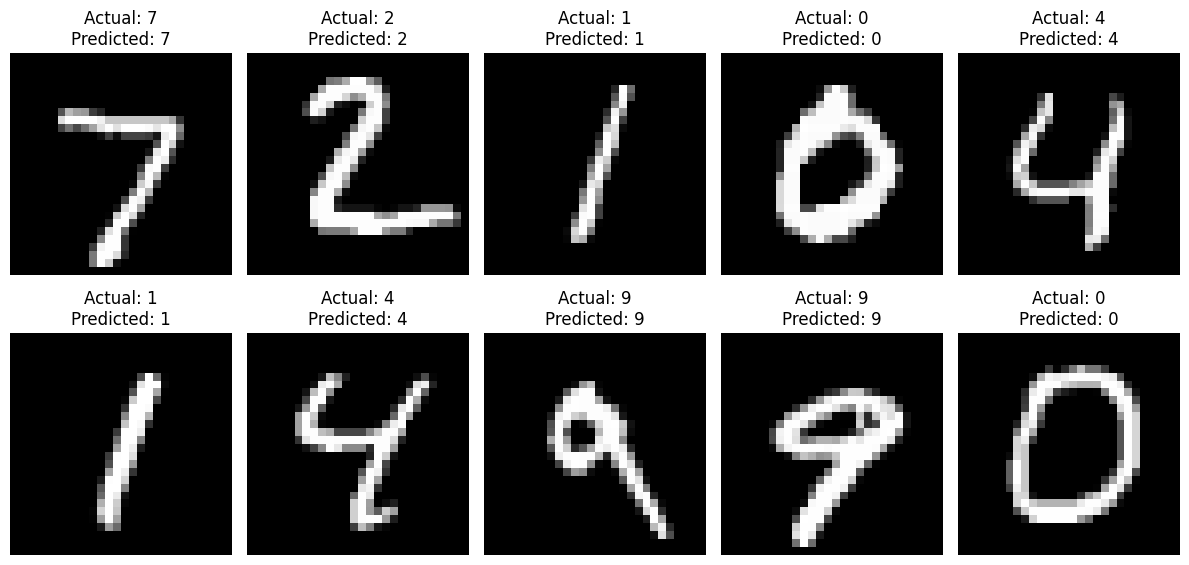

In [ ]:
correct_indices_relu = np.where(
    y_pred_relu_labels == y_test
)[0]

print("Total correctly classified:",
      len(correct_indices_relu))

# Display 10 correctly classified images
plt.figure(figsize=(12, 6))

for i, index in enumerate(correct_indices_relu[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[index], cmap="gray")
    plt.title(
        f"Actual: {y_test[index]}\nPredicted: {y_pred_relu_labels[index]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

**Misclassified Images for ReLU**

Number of misclassified images: 230


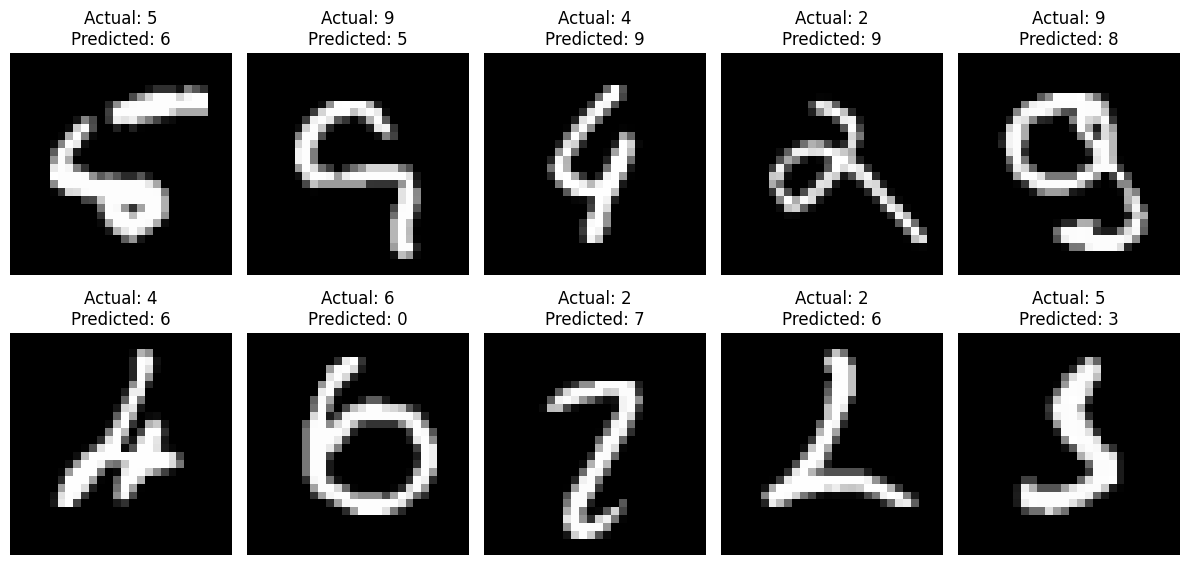

In [ ]:
misclassified_indices = np.where(
    y_pred_relu_labels != y_test)[0]

print("Number of misclassified images:", len(misclassified_indices))
# Display some misclassified images

plt.figure(figsize=(12, 6))

for i, index in enumerate(misclassified_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[index], cmap="gray")
    plt.title(
        f"Actual: {y_test[index]}\nPredicted: {y_pred_relu_labels[index]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

**Classified Images for Sigmoid**

Total correctly classified: 9733


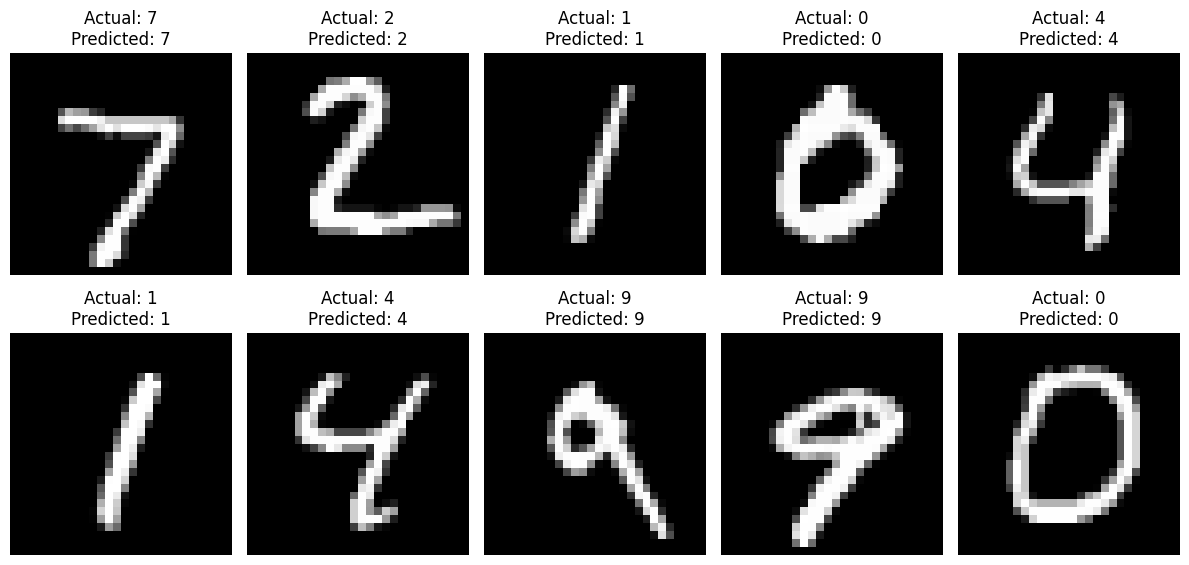

In [ ]:
# Find correctly classified images - Sigmoid

correct_indices_sigmoid = np.where(
    y_pred_sigmoid_labels == y_test
)[0]

print("Total correctly classified:",
      len(correct_indices_sigmoid))

# Display 10 correctly classified images
plt.figure(figsize=(12, 6))

for i, index in enumerate(correct_indices_sigmoid[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[index], cmap="gray")
    plt.title(
        f"Actual: {y_test[index]}\nPredicted: {y_pred_sigmoid_labels[index]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

**Misclassified Images for Sigmoid**

Number of misclassified images: 267


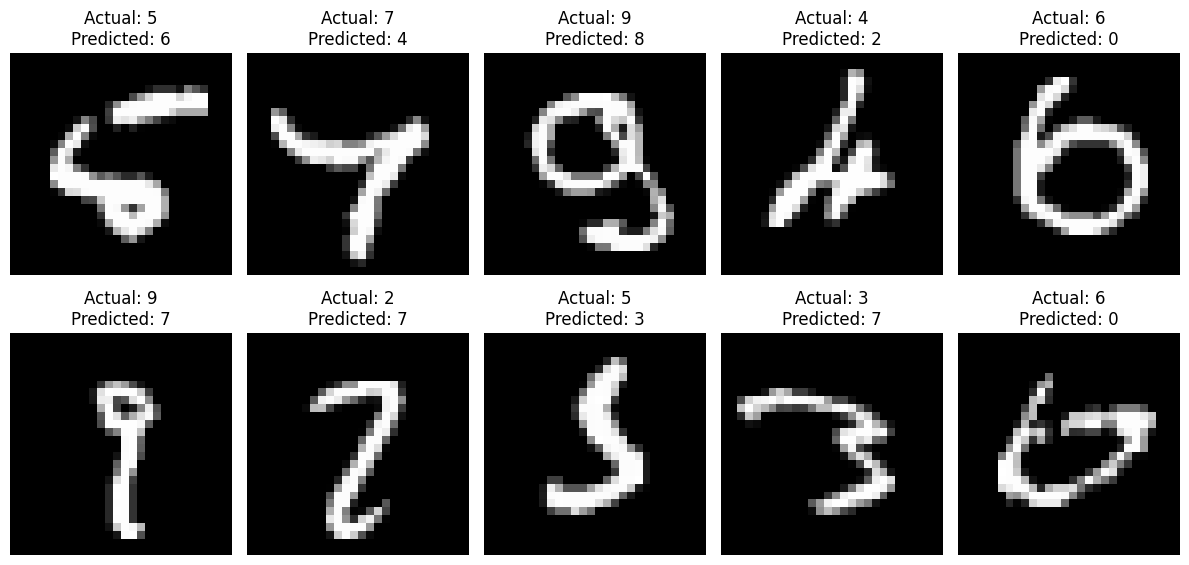

In [ ]:
misclassified_indices_sigmoid = np.where(
    y_pred_sigmoid_labels != y_test)[0]

print(
    "Number of misclassified images:",
    len(misclassified_indices_sigmoid)
)
# Display some misclassified Sigmoid images

plt.figure(figsize=(12, 6))

for i, index in enumerate(misclassified_indices_sigmoid[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[index], cmap="gray")
    plt.title(
        f"Actual: {y_test[index]}\nPredicted: {y_pred_sigmoid_labels[index]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

**Final comparison of Sigmoid and ReLU**

In [ ]:
final_comparison = pd.DataFrame({
    "Model": ["Sigmoid", "ReLU"],
    "Test Accuracy (%)": [
        test_accuracy_sigmoid * 100,
        test_accuracy_relu * 100
    ],
    "Test Loss": [
        test_loss_sigmoid,
        test_loss_relu
    ],
    "Misclassified Images": [
        len(misclassified_indices_sigmoid),
        len(misclassified_indices)
    ]
})

final_comparison

,Model,Test Accuracy (%),Test Loss,Misclassified Images
0,Sigmoid,97.329998,0.085978,267
1,ReLU,97.700000,0.078615,230


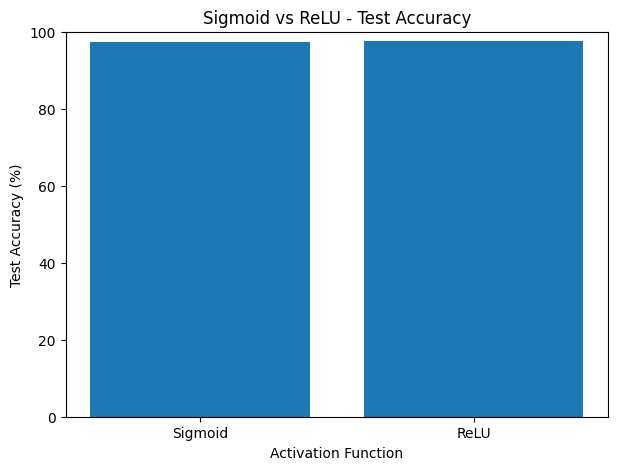

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Test Accuracy (%)"]
)

plt.xlabel("Activation Function")
plt.ylabel("Test Accuracy (%)")
plt.title("Sigmoid vs ReLU - Test Accuracy")

plt.ylim(0, 100)
plt.show()

# Project Workflow

**MNIST Dataset**  
↓  
**Preprocessing**  
↓  
**784 Input Features**  
↓  
**Sigmoid Model**  
`784 → 128 → 64 → 10`  
↓  
**Training + Testing**  
↓  
**Confusion Matrix + Classification Report**  
↓  
**ReLU Model**  
`784 → 128 → 64 → 10`  
↓  
**Training + Testing**  
↓  
**Confusion Matrix + Classification Report**  
↓  
**Final Comparison**

In [ ]:
print("Sigmoid Test Accuracy:", test_accuracy_sigmoid)
print("Sigmoid Test Loss:", test_loss_sigmoid)

print("ReLU Test Accuracy:", test_accuracy_relu)
print("ReLU Test Loss:", test_loss_relu)

print("Sigmoid Misclassified:", len(misclassified_indices_sigmoid))
print("ReLU Misclassified:", len(misclassified_indices))

Sigmoid Test Accuracy: 0.9732999801635742
Sigmoid Test Loss: 0.08597781509160995
ReLU Test Accuracy: 0.9769999980926514
ReLU Test Loss: 0.07861501723527908
Sigmoid Misclassified: 267
ReLU Misclassified: 230
